## 1. Imports + cosmology

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import treecorr
from astropy.table import Table, vstack

# Manual flat-LCDM angular diameter distance for the cluster-radius
# conversion (no external cosmology dependency).
z_cl = 0.22
H0, c_light = 70.0, 3e5
omega_m, omega_de = 0.31, 0.69
Hz = lambda z: c_light / (H0 * np.sqrt(omega_de + omega_m * (1 + z) ** 3))
chi_dl = lambda z, z0=0: integrate.quad(Hz, z0, z)[0]
Da = lambda z: chi_dl(z) / (1 + z)
Da_lens = Da(z_cl)
print(f'Da(z_cl={z_cl}) = {Da_lens:.1f} Mpc')

Da(z_cl=0.22) = 732.0 Mpc


## 2. Load the merged tract catalog

In [4]:
DATA_DIR = '/home/xiangchong/work/DP1'
TRACT_FILES = {
    10463: 'a360_merged_tract10463.parq',
    10464: 'a360_merged_tract10464.parq',
    10704: 'a360_merged_tract10704.parq',
}

cluster_coords = (37.865017, 6.982205)
ra_bcg, dec_bcg = cluster_coords

tables = []
for tid, fname in TRACT_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.isfile(path):
        print(f'  tract={tid}: NO file at {path}')
        continue
    t = Table.read(path)
    tables.append(t)
    print(f'  tract={tid}: {len(t)} objects ({fname})')

anacal_table = vstack(tables)
print(f'\nTotal merged objects: {len(anacal_table)}')

  tract=10463: 45176 objects (a360_merged_tract10463.parq)
  tract=10464: 25104 objects (a360_merged_tract10464.parq)
  tract=10704: 3861 objects (a360_merged_tract10704.parq)

Total merged objects: 74141


## 3. Per-band magnitudes

In [5]:
mag_zero = 31.4
for band in 'griz':
    flux = np.asarray(anacal_table[f'{band}_flux_fpfs1'])
    mag = np.full(len(anacal_table), 40.0)
    pos = flux > 0
    mag[pos] = mag_zero - 2.5 * np.log10(flux[pos])
    anacal_table[f'{band}_mag'] = mag

## 4. Selection (with shear-perturbed observables)

Cuts (matching the old notebook + new ``zbest`` cut):

- ``mask_value < 40``
- ``wsel > 1e-5``
- per-band magnitude limits ``g/r/z < 25.5``, ``i < 24.0``
- size-like cut ``(m00 + m20) / m00 > 0.1`` — uses the band-combined
  ``fpfs1_m00`` / ``fpfs1_m20`` since per-band ``i_fpfs1_m00`` /
  ``i_fpfs1_m20`` are not surfaced in the merged catalog
- red-sequence colour count < 3 (``g-i``, ``r-i``, ``g-r``, $r$-mag)
- photo-z ``Z_MIN < zbest < Z_MAX``

When ``dg_eff != 0`` the per-band fluxes, ``m00``, ``m20`` and the
photo-z column are all replaced by their first-order Taylor expansions
in the chosen shear component, mirroring ``selection.get_cut`` in
``HSC_S23B_Shapes``.

In [10]:
DG = 0.01
Z_MIN, Z_MAX = 0.2, 10.0
MAG_CUTS = {'g': 25.5, 'r': 25.5, 'i': 23.5, 'z': 25.5}
MAG_LIM_REDSEQ = 24.0


def _flux_to_mag(flux):
    mag = np.full(len(flux), 40.0)
    pos = flux > 0
    mag[pos] = mag_zero - 2.5 * np.log10(flux[pos])
    return mag


def _band_mag(t, band, dg_eff, comp):
    flux = np.asarray(t[f'{band}_flux_fpfs1'])
    if dg_eff != 0.0:
        flux = flux + dg_eff * np.asarray(t[f'{band}_dflux_fpfs1_dg{comp}'])
    return _flux_to_mag(flux)


def _redseq_count(g_mag, r_mag, i_mag):
    color_gi = g_mag - i_mag
    color_ri = r_mag - i_mag
    color_gr = g_mag - r_mag
    gi_line = (r_mag - 18) * (-0.20 / 5) + 2.15
    ri_line = (r_mag - 18) * (-0.10 / 5) + 0.85
    gr_line = (r_mag - 18) * (-0.12 / 5) + 1.35
    gi_lims, ri_lims, gr_lims = (0.20, -0.20), (0.12, -0.15), (0.15, -0.16)
    in_redseq = lambda c, line, lims: (
        (c < line + lims[0]) & (c > line + lims[1]) & (r_mag < MAG_LIM_REDSEQ)
    )
    return (
        in_redseq(color_gi, gi_line, gi_lims).astype(int)
        + in_redseq(color_ri, ri_line, ri_lims).astype(int)
        + in_redseq(color_gr, gr_line, gr_lims).astype(int)
    )


def get_cut(t, *, comp=1, dg_eff=0.0, zkey='zbest'):
    """Boolean mask for the standard selection.

    The merged catalog is already filtered by ``wsel > 1e-5`` in
    ``MergePipe._finalize_columns``; ``dg_eff != 0`` perturbs every
    other shear-dependent observable by its first-order response so the
    resulting cut feeds the selection-response finite difference.
    """
    mags = {b: _band_mag(t, b, dg_eff, comp) for b in 'griz'}

    mask = np.asarray(t['mask_value']) < 40
    for b, lim in MAG_CUTS.items():
        mask &= mags[b] < lim

    m00 = np.asarray(t['fpfs1_m00'])
    m20 = np.asarray(t['fpfs1_m20'])
    if dg_eff != 0.0:
        m00 = m00 + dg_eff * np.asarray(t[f'fpfs1_dm00_dg{comp}'])
        m20 = m20 + dg_eff * np.asarray(t[f'fpfs1_dm20_dg{comp}'])
    mask &= (m00 + m20) / m00 > 0.1

    counts = _redseq_count(mags['g'], mags['r'], mags['i'])
    mask &= counts < 3

    if dg_eff == 0.0:
        zcol = np.asarray(t[f'{zkey}_0'])
    else:
        suffix = 'p' if dg_eff > 0 else 'm'
        zcol = np.asarray(t[f'{zkey}_{comp}{suffix}'])
    mask &= (zcol > Z_MIN) & (zcol < Z_MAX)
    return mask


fid_cut = get_cut(anacal_table, dg_eff=0.0)
cut_p1 = get_cut(anacal_table, comp=1, dg_eff=+DG)
cut_m1 = get_cut(anacal_table, comp=1, dg_eff=-DG)
cut_p2 = get_cut(anacal_table, comp=2, dg_eff=+DG)
cut_m2 = get_cut(anacal_table, comp=2, dg_eff=-DG)
print(f'Fiducial selected: {int(fid_cut.sum())}/{len(anacal_table)}')
for tag, c in [('1p', cut_p1), ('1m', cut_m1), ('2p', cut_p2), ('2m', cut_m2)]:
    print(f'  cut_{tag}: {int(c.sum())}')

Fiducial selected: 17051/74141
  cut_1p: 17055
  cut_1m: 17040
  cut_2p: 17045
  cut_2m: 17048


In [11]:
# --- response components (computed *before* TreeCorr so the calibrated
# ellipticities can be fed directly to it) ---
nc = int(fid_cut.sum())
sub = anacal_table[fid_cut]
wsel = np.asarray(sub['wsel'])
e1 = np.asarray(sub['fpfs1_e1'])
e2 = np.asarray(sub['fpfs1_e2'])
de1_dg1 = np.asarray(sub['fpfs1_de1_dg1'])
de2_dg2 = np.asarray(sub['fpfs1_de2_dg2'])
dwsel_dg1 = np.asarray(sub['dwsel_dg1'])
dwsel_dg2 = np.asarray(sub['dwsel_dg2'])

# Shape (pure-shear) response: <w * de_i/dg_i> averaged over i = 1, 2
R_shape = 0.5 * (np.mean(wsel * de1_dg1) + np.mean(wsel * de2_dg2))
# Weight-bias response: <dw/dg_i * e_i> averaged over i = 1, 2
R_weight = 0.5 * (np.mean(dwsel_dg1 * e1) + np.mean(dwsel_dg2 * e2))


def _sum_we(t, cut, comp):
    s = t[cut]
    e_col = 'fpfs1_e1' if comp == 1 else 'fpfs1_e2'
    return float(np.sum(np.asarray(s['wsel']) * np.asarray(s[e_col])))


R_sel_1 = (_sum_we(anacal_table, cut_p1, 1) - _sum_we(anacal_table, cut_m1, 1)) / (2.0 * DG) / nc
R_sel_2 = (_sum_we(anacal_table, cut_p2, 2) - _sum_we(anacal_table, cut_m2, 2)) / (2.0 * DG) / nc
R_sel = 0.5 * (R_sel_1 + R_sel_2)

R_total = R_shape + R_weight + R_sel
print(f'N selected = {nc}')
print(f'  R_shape  = {R_shape:+.4f}')
print(f'  R_weight = {R_weight:+.4f}')
print(f'  R_sel    = {R_sel:+.4f}')
print(f'  R_total  = {R_total:+.4f}')

N selected = 17051
  R_shape  = +0.4481
  R_weight = -0.0233
  R_sel    = -0.0109
  R_total  = +0.4140


In [12]:
# --- TreeCorr: pre-calibrate the ellipticities by feeding
#     g1 = e1 * wsel / R_total
#     g2 = e2 * wsel / R_total
# (no sign flip on e2 -- merge.py keeps the WCS-corrected ellipticities
# in the GalSim u=W convention, which is what TreeCorr expects for the
# tangential / cross decomposition around the cluster centre)
# and pass w=None so TreeCorr does not re-weight. The resulting
# xi / xi_im are already the response- and weight-corrected tangential
# and cross shears.
bins_mpc = np.logspace(np.log10(0.5), np.log10(6.0), 7)
nbins = len(bins_mpc) - 1
mpc_to_arcmin = (1.0 / Da_lens) * (180.0 / np.pi) * 60.0
min_sep_arcmin = bins_mpc[0] * mpc_to_arcmin
max_sep_arcmin = bins_mpc[-1] * mpc_to_arcmin
print(f'min/max sep: {min_sep_arcmin:.2f} / {max_sep_arcmin:.2f} arcmin')
print(f'Mpc bin edges: {bins_mpc.round(3)}')

lens_cat = treecorr.Catalog(
    ra=[ra_bcg], dec=[dec_bcg], ra_units='deg', dec_units='deg',
)


def make_source_cat(t, cut, R_final):
    sub = t[cut]
    wsel_sub = np.asarray(sub['wsel'])
    g1 = np.asarray(sub['fpfs1_e1']) * wsel_sub / R_final
    g2 = np.asarray(sub['fpfs1_e2']) * wsel_sub / R_final
    return treecorr.Catalog(
        ra=np.asarray(sub['ra']),
        dec=np.asarray(sub['dec']),
        g1=g1, g2=g2, w=None,
        ra_units='deg', dec_units='deg',
    )


src_cat = make_source_cat(anacal_table, fid_cut, R_total)
ng = treecorr.NGCorrelation(
    min_sep=min_sep_arcmin, max_sep=max_sep_arcmin,
    nbins=nbins, sep_units='arcmin', bin_type='Log',
)
ng.process(lens_cat, src_cat)
mean_r_arcmin = ng.meanr
mean_r_mpc = mean_r_arcmin / mpc_to_arcmin
print('mean_r (Mpc):', np.round(mean_r_mpc, 3))

min/max sep: 2.35 / 28.18 arcmin
Mpc bin edges: [0.5   0.757 1.145 1.732 2.621 3.965 6.   ]
mean_r (Mpc): [0.633 0.956 1.445 2.183 3.309 5.121]


## 7. Tangential / cross shear profile

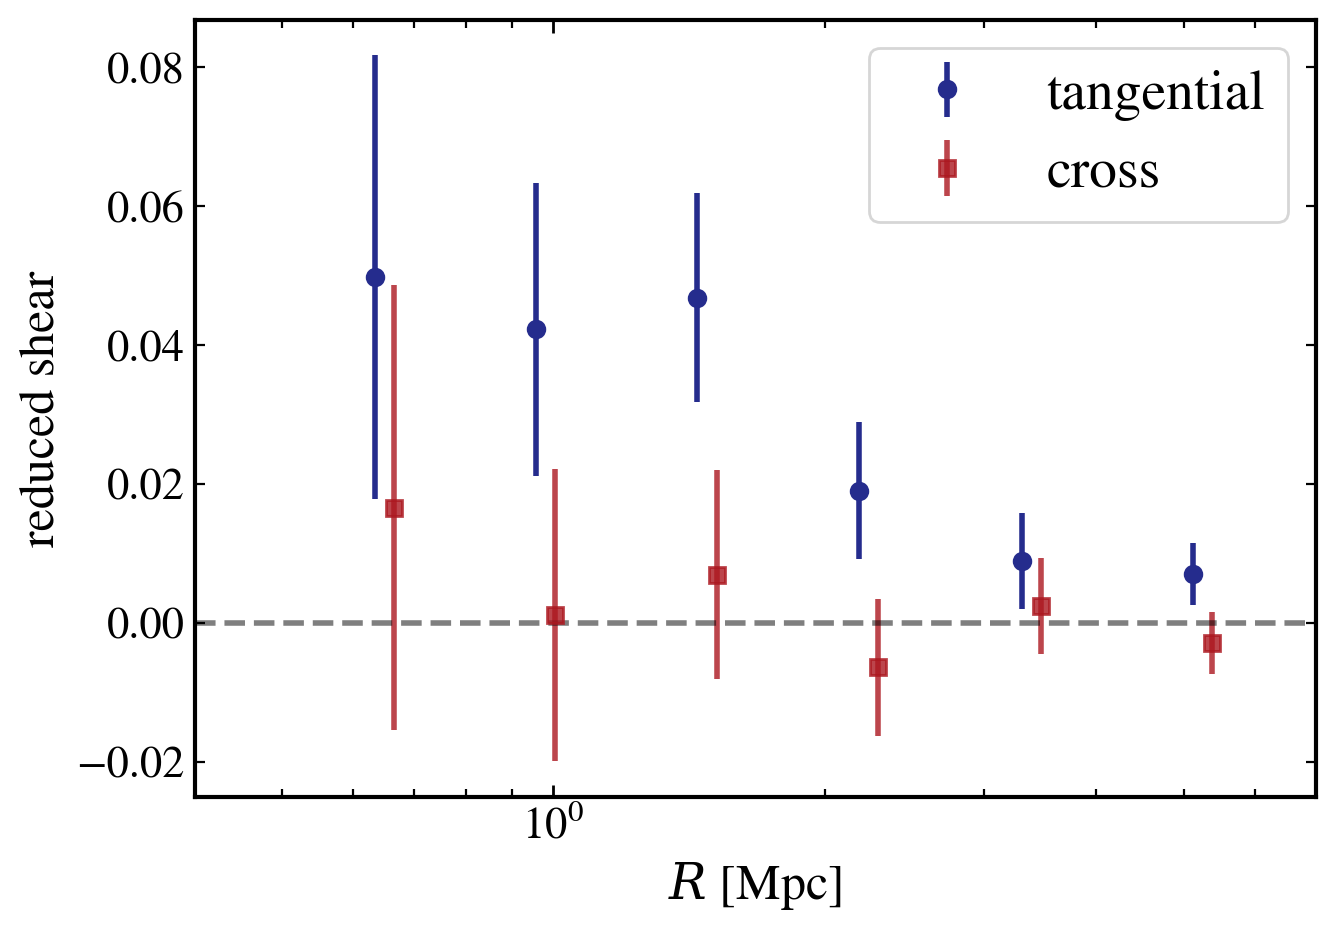

In [13]:
# xi / xi_im are already calibrated (no /R_total here -- the input
# ellipticities were pre-divided by R_total).
gT = ng.xi
gX = ng.xi_im
err = np.sqrt(ng.varxi)

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(mean_r_mpc, gT, yerr=err, fmt='o', label='tangential', color='C0')
ax.errorbar(mean_r_mpc * 1.05, gX, yerr=err, fmt='s', label='cross', color='C3', alpha=0.8)
ax.axhline(0, ls='--', color='k', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('$R$ [Mpc]')
ax.set_ylabel('reduced shear')
ax.set_xlim(0.4, 7.0)
ax.legend()
plt.tight_layout()
plt.show()